# # McCall Job Search Model 1 

In [2]:
## 0) Imports


import numpy as np
import matplotlib.pyplot as plt
import math
import mpmath as mp

print("Imports OK")

Imports OK


# McCall Model Solver (Value Iteration) + Convergence Checks + Weighted Accept Prob

In [3]:
def solve_mccall_checked(w, q, c=25.0, beta=0.99, tol=1e-10, max_iter=200_000):
    """
    Discrete McCall job search model (Model 1).

    Inputs
    ------
    w : (n,) wage grid
    q : (n,) probability mass on wages (sum to 1)
    c : unemployment benefit
    beta : discount factor
    tol : convergence tolerance for value iteration
    max_iter : max iterations

    Returns
    -------
    v_star : (n,) value function at fixed point
    w_bar  : float, reservation wage
    accept : (n,) boolean mask, True => accept at wage
    accept_prob : float, probability-weighted accept probability sum_i q_i 1{w_i >= w_bar}
    converged : bool
    iters : int, number of iterations performed
    sup_error : float, final sup-norm error
    """
    w = np.asarray(w, float)
    q = np.asarray(q, float)
    q = q / q.sum()

    # initial guess: accept everywhere
    v = w / (1 - beta)

    converged = False
    sup_error = np.inf
    iters = 0

    for it in range(1, max_iter + 1):
        R = c + beta * np.dot(v, q)                 # continuation value if reject (scalar)
        v_new = np.maximum(w / (1 - beta), R)       # Bellman update
        sup_error = float(np.max(np.abs(v_new - v)))

        v = v_new
        iters = it

        if sup_error < tol:
            converged = True
            break

    # fixed-point quantities
    R = c + beta * np.dot(v, q)
    w_bar = (1 - beta) * R

    accept = (w >= w_bar)

    # "real" accept probability (weighted)
    accept_prob = float(np.dot(q, accept.astype(float)))

    return v, float(w_bar), accept, accept_prob, converged, iters, sup_error

# Wage Grid + Distribution Builders (Uniform / Lognormal / Mixture / Beta-Binomial)

In [13]:
def wage_grid(w_min=10, w_max=60, n=50):
    # n=50 => n+1 points => 51 wages
    return np.linspace(w_min, w_max, n+1)

def q_uniform(w):
    return np.ones_like(w, dtype=float) / len(w)

def q_lognormal_discretized(w, median=30.0, sigma=0.4):
    """
    Build q(w) by evaluating a lognormal pdf on the grid and normalizing.
    """
    mu = math.log(median)
    dens = (1/(w*sigma*math.sqrt(2*math.pi))) * np.exp(-(np.log(w)-mu)**2/(2*sigma**2))
    q = dens / dens.sum()
    return q

def q_mixture_normals(w, weight=0.7, m1=20, s1=5, m2=50, s2=4):
    """
    Two-normal mixture on grid, then normalized.
    """
    def norm_pdf(x, m, s):
        return (1/(s*math.sqrt(2*math.pi))) * np.exp(-(x-m)**2/(2*s**2))

    mix = weight * norm_pdf(w, m1, s1) + (1-weight) * norm_pdf(w, m2, s2)
    return mix / mix.sum()

def q_beta_binomial(n=50, a=200, b=100):
    """
    Beta-Binomial pmf over k=0..n (length n+1).
    You should use a wage grid of length n+1 to match.
    """
    pmf = []
    for k in range(n+1):
        pmf.append(mp.binomial(n, k) * mp.beta(k+a, n-k+b) / mp.beta(a, b))
    q = np.array([float(x) for x in pmf])
    return q / q.sum()

# Baseline Run ( Beta Bionomial distribution, compute optimal policy)

In [5]:
# Wage grid
w = wage_grid(10, 60, n=50)


q = q_beta_binomial(n=50, a=200, b=100)      # QuantEcon-style example
# q = q_uniform(w)
# q = q_lognormal_discretized(w, median=30, sigma=0.4)
# q = q_mixture_normals(w, weight=0.7, m1=20, s1=5, m2=50, s2=4)

# Parameters
c = 25.0
beta = 0.99

# Solve
v, w_bar, accept, accept_prob, converged, iters, err = solve_mccall_checked(
    w, q, c=c, beta=beta, tol=1e-10, max_iter=200_000
)

print("=== McCall Model 1 (checked) ===")
print("converged:", converged)
print("iterations:", iters)
print("final sup error:", err)
if not converged:
    print("WARNING: did not converge — try larger max_iter or looser tol.")

print("reservation wage w_bar:", w_bar)
print("accept probability (weighted by q):", accept_prob)
print("grid fraction accepted (unweighted):", accept.mean())

=== McCall Model 1 (checked) ===
converged: True
iterations: 189
final sup error: 9.549694368615746e-11
reservation wage w_bar: 47.31649976652067
accept probability (weighted by q): 0.1217294359539823
grid fraction accepted (unweighted): 0.2549019607843137


# Plot: q(w) + Reservation Wage + Accept/Reject Markers

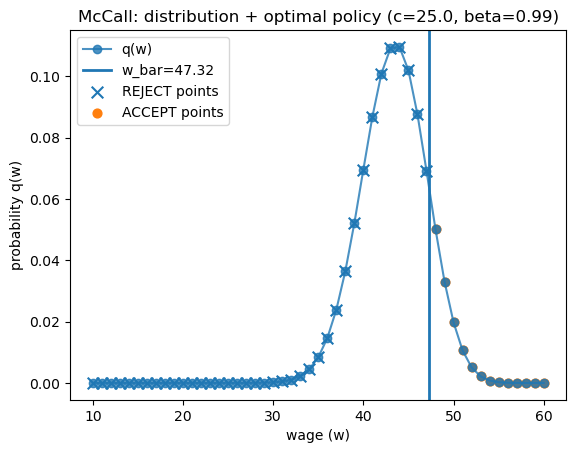

In [6]:
fig, ax = plt.subplots()
ax.plot(w, q, marker="o", linewidth=1.5, alpha=0.8, label="q(w)")

ax.axvline(w_bar, linewidth=2, label=f"w_bar={w_bar:.2f}")

# Mark accept / reject points
ax.scatter(w[~accept], q[~accept], marker="x", s=70, label="REJECT points")
ax.scatter(w[accept],  q[accept],  marker="o", s=40, label="ACCEPT points")

ax.set_xlabel("wage (w)")
ax.set_ylabel("probability q(w)")
ax.set_title(f"McCall: distribution + optimal policy (c={c}, beta={beta})")
ax.legend()
plt.show()

# Compare Distributions (w_bar + accept probability)

In [7]:
dists = {
    "Uniform": q_uniform(w),
    "Lognormal (disc.)": q_lognormal_discretized(w, median=30, sigma=0.4),
    "Mixture": q_mixture_normals(w, weight=0.7, m1=20, s1=5, m2=50, s2=4),
    "Beta-Binomial": q_beta_binomial(n=50, a=200, b=100),
}

for name, qi in dists.items():
    _, wb, _, ap, conv, it, e = solve_mccall_checked(w, qi, c=c, beta=beta)
    print(f"{name:18s} | w_bar={wb:8.3f} | accept_prob={ap:7.3f} | converged={conv}")

Uniform            | w_bar=  54.930 | accept_prob=  0.118 | converged=True
Lognormal (disc.)  | w_bar=  50.447 | accept_prob=  0.059 | converged=True
Mixture            | w_bar=  51.596 | accept_prob=  0.106 | converged=True
Beta-Binomial      | w_bar=  47.316 | accept_prob=  0.122 | converged=True


# One Figure: All q(w) Curves + Their Reservation Wages

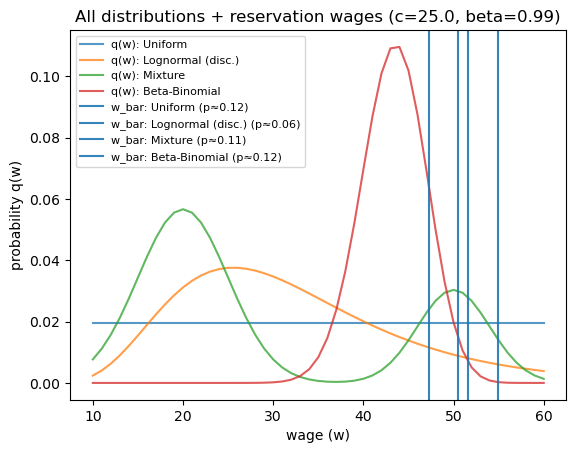

In [8]:
fig, ax = plt.subplots()

for name, qi in dists.items():
    ax.plot(w, qi, linewidth=1.5, alpha=0.75, label=f"q(w): {name}")

for name, qi in dists.items():
    _, wb, _, ap, _, _, _ = solve_mccall_checked(w, qi, c=c, beta=beta)
    ax.axvline(wb, linewidth=1.5, alpha=0.9, label=f"w_bar: {name} (p≈{ap:.2f})")

ax.set_xlabel("wage (w)")
ax.set_ylabel("probability q(w)")
ax.set_title(f"All distributions + reservation wages (c={c}, beta={beta})")
ax.legend(fontsize=8)
plt.show()

# Comparative Statics in c

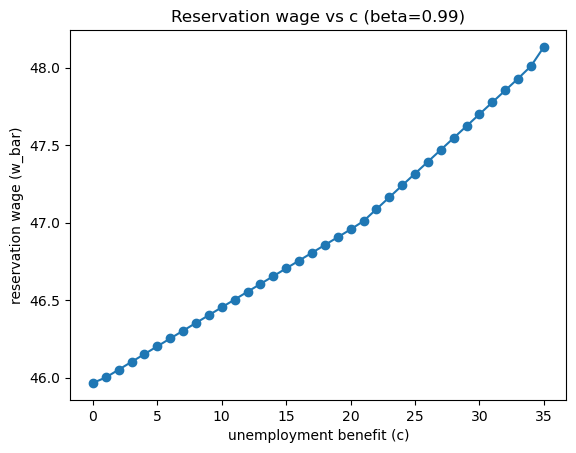

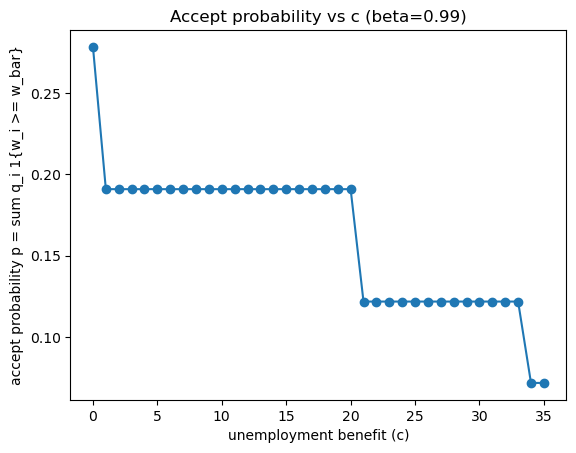

In [9]:
# Beta-Bionomial  distribution to study vs c
q_cs = dists["Beta-Binomial"]   # change to "Uniform" / "Lognormal (disc.)" / "Mixture"
beta_cs = 0.99

c_grid = np.linspace(0, 35, 36)

w_bars = []
accept_probs = []
for c_val in c_grid:
    _, wb, _, ap, _, _, _ = solve_mccall_checked(w, q_cs, c=float(c_val), beta=beta_cs)
    w_bars.append(wb)
    accept_probs.append(ap)

# Plot w_bar vs c
fig, ax = plt.subplots()
ax.plot(c_grid, w_bars, marker="o", linewidth=1.5)
ax.set_xlabel("unemployment benefit (c)")
ax.set_ylabel("reservation wage (w_bar)")
ax.set_title(f"Reservation wage vs c (beta={beta_cs})")
plt.show()

# Plot accept probability vs c
fig, ax = plt.subplots()
ax.plot(c_grid, accept_probs, marker="o", linewidth=1.5)
ax.set_xlabel("unemployment benefit (c)")
ax.set_ylabel("accept probability p = sum q_i 1{w_i >= w_bar}")
ax.set_title(f"Accept probability vs c (beta={beta_cs})")
plt.show()

# Comparative Statics in beta (beta ↑ => usually w_bar ↑, accept prob ↓)

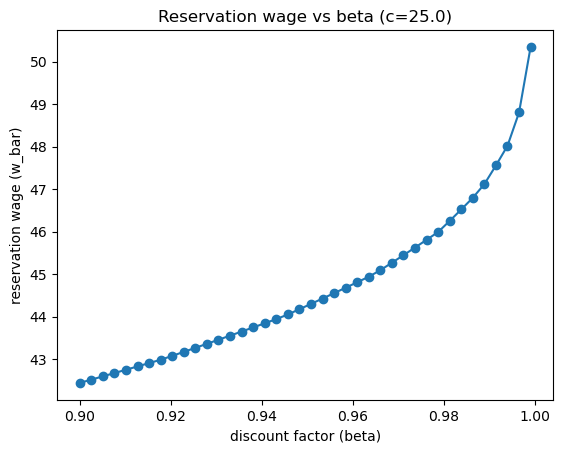

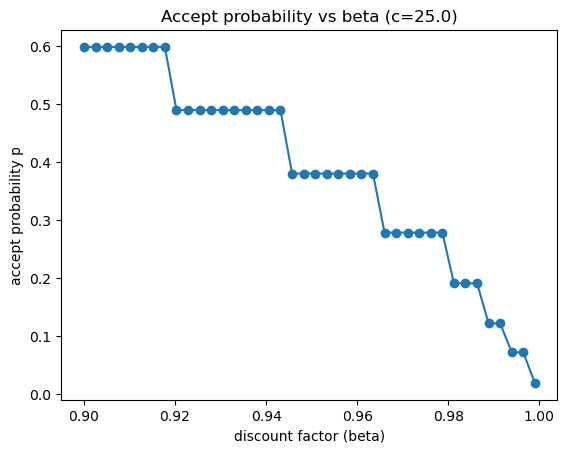

In [10]:
q_cs = dists["Beta-Binomial"]   # distribution fixed
c_cs = 25.0

beta_grid = np.linspace(0.90, 0.999, 40)

w_bars = []
accept_probs = []
for beta_val in beta_grid:
    _, wb, _, ap, _, _, _ = solve_mccall_checked(w, q_cs, c=c_cs, beta=float(beta_val))
    w_bars.append(wb)
    accept_probs.append(ap)

# Plot w_bar vs beta
fig, ax = plt.subplots()
ax.plot(beta_grid, w_bars, marker="o", linewidth=1.5)
ax.set_xlabel("discount factor (beta)")
ax.set_ylabel("reservation wage (w_bar)")
ax.set_title(f"Reservation wage vs beta (c={c_cs})")
plt.show()

# Plot accept probability vs beta
fig, ax = plt.subplots()
ax.plot(beta_grid, accept_probs, marker="o", linewidth=1.5)
ax.set_xlabel("discount factor (beta)")
ax.set_ylabel("accept probability p")
ax.set_title(f"Accept probability vs beta (c={c_cs})")
plt.show()

# Simulation: Theory vs Simulation for Unemployment Duration
Theory (Geometric)

If each period accept probability is p, then:

Expected periods until accept: 1/p

Expected rejections before accept: (1-p)/p

In [11]:
def simulate_one_spell(w, q, w_bar, rng=None, max_steps=1_000_000):
    """
    Simulate one unemployment spell until acceptance.
    Returns:
      rejections_before_accept (int),
      accepted_wage (float),
      periods_until_accept (int)
    """
    if rng is None:
        rng = np.random.default_rng()

    w = np.asarray(w, float)
    q = np.asarray(q, float)
    q = q / q.sum()

    rejections = 0
    periods = 0

    for _ in range(max_steps):
        periods += 1
        offer = rng.choice(w, p=q)
        if offer >= w_bar:
            return rejections, float(offer), periods
        rejections += 1

    return rejections, float("nan"), periods

def simulate_many(w, q, w_bar, N=5000, seed=123):
    rng = np.random.default_rng(seed)
    rejs = np.empty(N, dtype=int)
    accw = np.empty(N, dtype=float)
    pers = np.empty(N, dtype=int)

    for i in range(N):
        r, aw, p = simulate_one_spell(w, q, w_bar, rng=rng)
        rejs[i] = r
        accw[i] = aw
        pers[i] = p

    return rejs, accw, pers

# Use the currently solved (w, q, w_bar, accept_prob) from Cell 3
p = accept_prob

E_periods_theory = 1.0 / p
E_rejections_theory = (1.0 - p) / p

print("=== Theory (geometric) ===")
print("accept probability p =", p)
print("E[periods until accept] ~", E_periods_theory)
print("E[rejections before accept] ~", E_rejections_theory)

# Simulate
rejs, accw, pers = simulate_many(w, q, w_bar, N=5000, seed=123)

print("\n=== Simulation ===")
print("Simulated mean periods:", pers.mean())
print("Simulated mean rejections:", rejs.mean())
print("Simulated mean accepted wage:", accw.mean())

=== Theory (geometric) ===
accept probability p = 0.1217294359539823
E[periods until accept] ~ 8.214939896526198
E[rejections before accept] ~ 7.214939896526199

=== Simulation ===
Simulated mean periods: 8.3562
Simulated mean rejections: 7.3562
Simulated mean accepted wage: 49.188


# Plots from Simulation

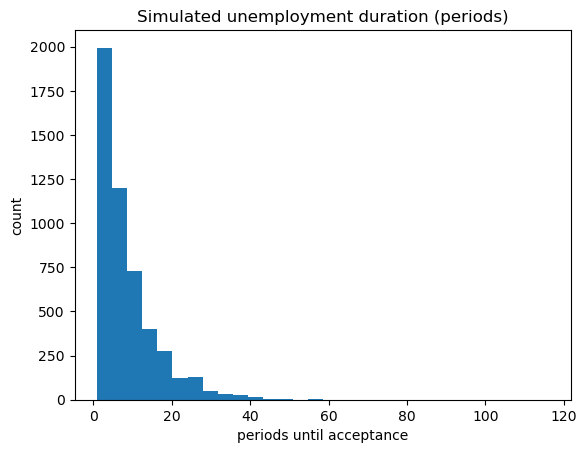

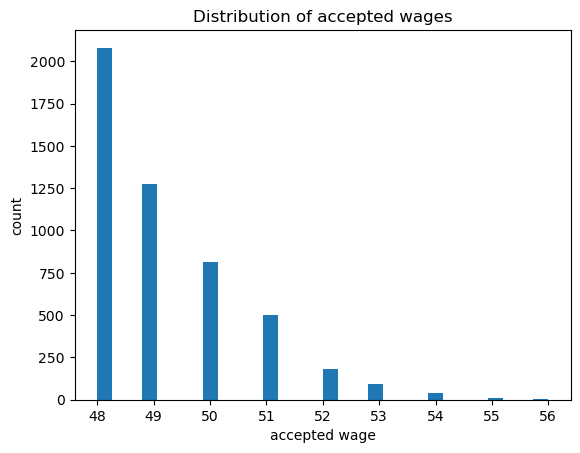

In [12]:
fig, ax = plt.subplots()
ax.hist(pers, bins=30)
ax.set_xlabel("periods until acceptance")
ax.set_ylabel("count")
ax.set_title("Simulated unemployment duration (periods)")
plt.show()

fig, ax = plt.subplots()
ax.hist(accw, bins=30)
ax.set_xlabel("accepted wage")
ax.set_ylabel("count")
ax.set_title("Distribution of accepted wages")
plt.show()